In [ ]:
# ============================================================
# Sliding Window YOLO Inference for Sentinel-1 .mat
# + Georeferenced lon/lat visualization
# ============================================================

!pip install -q ultralytics scipy h5py cartopy

from ultralytics import YOLO
import scipy.io as sio
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

from google.colab import drive
drive.mount('/content/drive')

# ------------------------------------------------------------
# 1. Path
# ------------------------------------------------------------
MODEL_PATH = "/content/drive/MyDrive/SAR_AI_Ship_Detection/trained_models/ls_ssdd_yolov8s_20epoch_best.pt"

MAT_PATH = "/content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_subset_4_of_S1A_IW_GRDH_1SDV_20250508T092324_20250508T092353_059101_075525_2036_tnr_Bdr_Cal.mat"

SAVE_PIXEL_PATH = "/content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_20250508T092324_yolov8s_lsssdd_20epoch_sliding_result.png"
SAVE_MAP_PATH   = "/content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_20250508T092324_YOLOv8s_lsssdd_20epoch_Ship_Detection_Result.png"
SAVE_BOX_PATH   = "/content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_final_boxes.npy"

# ------------------------------------------------------------
# 2. Load model
# ------------------------------------------------------------
model = YOLO(MODEL_PATH)

# ------------------------------------------------------------
# 3. Load MAT variables
# ------------------------------------------------------------
def load_mat_variable(mat_path, var_name):
    try:
        return sio.loadmat(mat_path, variable_names=[var_name])[var_name]
    except NotImplementedError:
        with h5py.File(mat_path, "r") as f:
            return np.array(f[var_name])

print("Loading sigma_naught...")
sar = load_mat_variable(MAT_PATH, "sigma_naught").squeeze().astype(np.float32)

print("Loading xx...")
xx = load_mat_variable(MAT_PATH, "xx").squeeze().astype(np.float32)

print("Loading yy...")
yy = load_mat_variable(MAT_PATH, "yy").squeeze().astype(np.float32)

print("SAR shape:", sar.shape)
print("xx shape :", xx.shape)
print("yy shape :", yy.shape)
print("min/max:", np.nanmin(sar), np.nanmax(sar))

# Match the dimensions of the SAR image and the latitude/longitude grids
nrow = min(sar.shape[0], xx.shape[0], yy.shape[0])
ncol = min(sar.shape[1], xx.shape[1], yy.shape[1])

sar = sar[:nrow, :ncol]
xx  = xx[:nrow, :ncol]
yy  = yy[:nrow, :ncol]

# ------------------------------------------------------------
# 4. SAR to uint8 RGB
# ------------------------------------------------------------
def sar_to_uint8_rgb(sar):
    sar = np.array(sar, dtype=np.float32)
    sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)

    if np.nanmin(sar) < -5:
        sar_db = np.clip(sar, -35, 5)
    else:
        sar = np.maximum(sar, 1e-8)
        sar_db = 10 * np.log10(sar)
        sar_db = np.clip(sar_db, -35, 5)

    img = (sar_db + 35) / 40
    img = np.clip(img, 0, 1)
    img = (img * 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img_rgb, sar_db

img_rgb, sar_db = sar_to_uint8_rgb(sar)

H, W = img_rgb.shape[:2]
print("Image size:", H, W)

# ------------------------------------------------------------
# 5. Sliding window inference
# ------------------------------------------------------------
tile_size =128
stride =64
conf_thres = 0.2
iou_thres = 0.2
min_box_area = 20

all_boxes = []

for y0 in range(0, H, stride):
    for x0 in range(0, W, stride):

        x1_tile = x0
        y1_tile = y0
        x2_tile = min(x0 + tile_size, W)
        y2_tile = min(y0 + tile_size, H)

        tile = img_rgb[y1_tile:y2_tile, x1_tile:x2_tile]
        th, tw = tile.shape[:2]

        if th < tile_size or tw < tile_size:
            padded = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
            padded[:th, :tw] = tile
            tile_input = padded
        else:
            tile_input = tile

        results = model.predict(
            source=tile_input,
            imgsz=tile_size,
            conf=conf_thres,
            iou=iou_thres,
            verbose=False
        )

        boxes = results[0].boxes

        for i in range(len(boxes)):
            bx1, by1, bx2, by2 = boxes.xyxy[i].cpu().numpy()
            conf = boxes.conf[i].item()

            if bx1 >= tw or by1 >= th:
                continue

            bx1 = min(bx1, tw)
            bx2 = min(bx2, tw)
            by1 = min(by1, th)
            by2 = min(by2, th)

            gx1 = bx1 + x1_tile
            gy1 = by1 + y1_tile
            gx2 = bx2 + x1_tile
            gy2 = by2 + y1_tile

            all_boxes.append([gx1, gy1, gx2, gy2, conf])

print("Raw detections:", len(all_boxes))

# ------------------------------------------------------------
# 6. NMS
# ------------------------------------------------------------
def nms_boxes(boxes, iou_threshold=0.5):
    if len(boxes) == 0:
        return []

    boxes_np = np.array(boxes)
    xyxy = boxes_np[:, :4]
    scores = boxes_np[:, 4]

    x1 = xyxy[:, 0]
    y1 = xyxy[:, 1]
    x2 = xyxy[:, 2]
    y2 = xyxy[:, 3]

    areas = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)
    order = scores.argsort()[::-1]

    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w_box = np.maximum(0, xx2 - xx1)
        h_box = np.maximum(0, yy2 - yy1)

        inter = w_box * h_box
        union = areas[i] + areas[order[1:]] - inter
        iou = inter / np.maximum(union, 1e-6)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return boxes_np[keep].tolist()

final_boxes = nms_boxes(all_boxes, iou_threshold=0.5)


# Filter
filtered_boxes = []

for box in final_boxes:

    x1, y1, x2, y2, conf = box

    area = (x2 - x1) * (y2 - y1)

    if area < 50:
        continue

    filtered_boxes.append(box)

final_boxes = filtered_boxes

print("Final detections after NMS:", len(final_boxes))

# ------------------------------------------------------------
# 6-1. Ship type classification using OpenSARShip2 classifier
# ------------------------------------------------------------
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd

CLASSIFIER_PATH = (
    "/content/drive/MyDrive/SAR_AI_Ship_Detection/trained_models/"
    "opensarship2_resnet18_3class_ship_classifier.pt"
)

SAVE_CLASS_CSV_PATH = (
    "/content/drive/MyDrive/SAR_AI_Ship_Detection/"
    "ship_detection_classification_results.csv"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint = torch.load(CLASSIFIER_PATH, map_location=device)

classes = checkpoint["classes"]
idx_to_class = checkpoint["idx_to_class"]
img_size = checkpoint["img_size"]

clf_model = models.resnet18(weights=None)
clf_model.fc = nn.Linear(clf_model.fc.in_features, len(classes))
clf_model.load_state_dict(checkpoint["model_state_dict"])
clf_model = clf_model.to(device)
clf_model.eval()

clf_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Loaded ship-type classes:", classes)

# ------------------------------------------------------------
# Crop detected ships and classify
# ------------------------------------------------------------
classified_boxes = []

cls_min_box_area = 50
crop_size = 512

for i, box in enumerate(final_boxes):

    gx1, gy1, gx2, gy2, det_conf = box

    bw = gx2 - gx1
    bh = gy2 - gy1
    area = bw * bh

    if area < cls_min_box_area:
        continue

    # Center of the YOLO bounding box
    cx = int(round((gx1 + gx2) / 2))
    cy = int(round((gy1 + gy2) / 2))

    # Extract a fixed-size crop centered on the bounding box
    x1 = cx - crop_size // 2
    y1 = cy - crop_size // 2
    x2 = cx + crop_size // 2
    y2 = cy + crop_size // 2

    # Adjust the crop to remain within the image boundaries
    if x1 < 0:
        x2 -= x1
        x1 = 0
    if y1 < 0:
        y2 -= y1
        y1 = 0
    if x2 > W:
        x1 -= (x2 - W)
        x2 = W
    if y2 > H:
        y1 -= (y2 - H)
        y2 = H

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    crop = img_rgb[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    if i < 10:
       print("box", i)
       print("crop shape:", crop.shape)
       print("crop mean/std:", np.mean(crop), np.std(crop))

    pil_img = Image.fromarray(crop).convert("RGB")
    input_tensor = clf_tf(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = clf_model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
    if i < 10:
        print("probs:", probs.cpu().numpy())
        print("pred:", idx_to_class[int(probs.argmax().item())])

    cls_idx = int(torch.argmax(probs).item())
    ship_type = idx_to_class[cls_idx]
    cls_conf = float(probs[cls_idx].item())

    classified_boxes.append([
        gx1, gy1, gx2, gy2,
        det_conf,
        ship_type,
        cls_conf
    ])

print("Classified ships:", len(classified_boxes))

df_cls = pd.DataFrame(
    classified_boxes,
    columns=[
        "x1", "y1", "x2", "y2",
        "det_conf",
        "ship_type",
        "cls_conf"
    ]
)

df_cls.to_csv(SAVE_CLASS_CSV_PATH, index=False)
print("Saved classification CSV:", SAVE_CLASS_CSV_PATH)
print(df_cls["ship_type"].value_counts())

# ------------------------------------------------------------
# 7. Pixel-coordinate visualization with ship type
# ------------------------------------------------------------
vis = img_rgb.copy()

for gx1, gy1, gx2, gy2, det_conf, ship_type, cls_conf in classified_boxes:

    cv2.rectangle(
        vis,
        (int(gx1), int(gy1)),
        (int(gx2), int(gy2)),
        (255, 0, 0),
        2
    )

    label = f"{ship_type} {cls_conf:.2f}"

    cv2.putText(
        vis,
        label,
        (int(gx1), max(0, int(gy1) - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(16, 16))
plt.imshow(vis)
plt.axis("off")
plt.title(
    f"YOLO Ship Detection + Ship Type Classification: "
    f"{len(classified_boxes)} ships"
)
plt.show()

SAVE_PIXEL_CLASS_PATH = (
    "/content/drive/MyDrive/SAR_AI_Ship_Detection/"
    "ship_detection_classification_pixel_result.png"
)

cv2.imwrite(
    SAVE_PIXEL_CLASS_PATH,
    cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
)

print("Saved pixel classification figure:", SAVE_PIXEL_CLASS_PATH)

# ------------------------------------------------------------
# bbox pixel coordinate -> lon/lat polygon
# ------------------------------------------------------------
def pixel_box_to_lonlat_poly(gx1, gy1, gx2, gy2, xx, yy, n=20):
    H_geo, W_geo = xx.shape

    gx1 = max(0, min(gx1, W_geo - 1))
    gx2 = max(0, min(gx2, W_geo - 1))
    gy1 = max(0, min(gy1, H_geo - 1))
    gy2 = max(0, min(gy2, H_geo - 1))

    top_x = np.linspace(gx1, gx2, n)
    top_y = np.full(n, gy1)

    right_x = np.full(n, gx2)
    right_y = np.linspace(gy1, gy2, n)

    bottom_x = np.linspace(gx2, gx1, n)
    bottom_y = np.full(n, gy2)

    left_x = np.full(n, gx1)
    left_y = np.linspace(gy2, gy1, n)

    xs = np.concatenate([top_x, right_x, bottom_x, left_x])
    ys = np.concatenate([top_y, right_y, bottom_y, left_y])

    xs = np.clip(np.round(xs).astype(int), 0, W_geo - 1)
    ys = np.clip(np.round(ys).astype(int), 0, H_geo - 1)

    return xx[ys, xs], yy[ys, xs]

# ------------------------------------------------------------
# 8. Georeferenced lon/lat visualization with ship type
# ------------------------------------------------------------

ds = 1

lon = xx[::ds, ::ds]
lat = yy[::ds, ::ds]
sar_plot = sar_db[::ds, ::ds]

map_conf_thres = 0.05
min_box_area = 50

map_boxes = []

for box in classified_boxes:

    gx1, gy1, gx2, gy2, det_conf, ship_type, cls_conf = box

    bw = gx2 - gx1
    bh = gy2 - gy1
    area = bw * bh

    if det_conf < map_conf_thres:
        continue

    if area < min_box_area:
        continue

    map_boxes.append([
        gx1, gy1, gx2, gy2,
        det_conf,
        ship_type,
        cls_conf
    ])

print("Map classified detections:", len(map_boxes))

box_lonlat = []

for gx1, gy1, gx2, gy2, det_conf, ship_type, cls_conf in map_boxes:

    box_lon, box_lat = pixel_box_to_lonlat_poly(
        gx1, gy1, gx2, gy2,
        xx, yy,
        n=20
    )

    if not (np.all(np.isfinite(box_lon)) and np.all(np.isfinite(box_lat))):
        continue

    xc = int(round((gx1 + gx2) / 2))
    yc = int(round((gy1 + gy2) / 2))

    xc = max(0, min(xc, xx.shape[1] - 1))
    yc = max(0, min(yc, xx.shape[0] - 1))

    text_lon = xx[yc, xc]
    text_lat = yy[yc, xc]

    if not (np.isfinite(text_lon) and np.isfinite(text_lat)):
        continue

    box_lonlat.append((
        box_lon,
        box_lat,
        det_conf,
        ship_type,
        cls_conf,
        text_lon,
        text_lat
    ))

nrow = min(lon.shape[0], lat.shape[0], sar_plot.shape[0])
ncol = min(lon.shape[1], lat.shape[1], sar_plot.shape[1])

lon = lon[:nrow, :ncol]
lat = lat[:nrow, :ncol]
sar_plot = sar_plot[:nrow, :ncol]

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([
    np.nanmin(lon), np.nanmax(lon),
    np.nanmin(lat), np.nanmax(lat)
], crs=ccrs.PlateCarree())

sar_plot = cv2.GaussianBlur(
    sar_plot,
    (3, 3),
    0
)

im = ax.pcolormesh(
    lon,
    lat,
    sar_plot,
    cmap="gray",
    shading="auto",
    transform=ccrs.PlateCarree()
)

# ------------------------------------------------------------
# Class color setting
# ------------------------------------------------------------
CLASS_COLORS = {
    "Cargo": "#87CEEB",      # SkyBlue
    "Tanker": "#FFA500",     # Orange
    "Other Type": "yellow", # LimeGreen
    "Fishing": "#FFD700",    # Gold
    "Passenger": "#FF69B4",  # HotPink
    "Tug": "#9370DB",        # MediumPurple
    "Etc": "#A9A9A9"         # DarkGray
}

# ------------------------------------------------------------
# Draw class-colored boxes
# ------------------------------------------------------------
for box_lon, box_lat, det_conf, ship_type, cls_conf, text_lon, text_lat in box_lonlat:

    color = CLASS_COLORS.get(ship_type, "white")

    ax.plot(
        box_lon,
        box_lat,
        color=color,
        linewidth=1.6,
        transform=ccrs.PlateCarree(),
        zorder=4
    )

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.7
)

gl.top_labels = False
gl.right_labels = False

# ------------------------------------------------------------
# Class legend
# ------------------------------------------------------------
legend_handles = []

used_classes = sorted(
    list(set([item[3] for item in box_lonlat]))
)

for cls in used_classes:

    color = CLASS_COLORS.get(cls, "white")

    legend_handles.append(
        Line2D(
            [0], [0],
            color=color,
            lw=3,
            label=cls
        )
    )

ax.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=9,
    frameon=True
)

plt.title(
    f"Ship Classification\n"
    f"Ulsan 2025-05-08 T09:23:24\n"
    f"Detected ships: {len(box_lonlat)}",
    fontsize=14,
    fontweight="bold"
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.10,
    axes_class=plt.Axes
)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Sigma0 VV (dB)")

SAVE_MAP_CLASS_PATH = (
    "/content/drive/MyDrive/SAR_AI_Ship_Detection/"
    "Ulsan_20250508T092324_Ship_classification_result.png"
)

plt.savefig(SAVE_MAP_CLASS_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved lon/lat classification figure:", SAVE_MAP_CLASS_PATH)

Output hidden; open in https://colab.research.google.com to view.

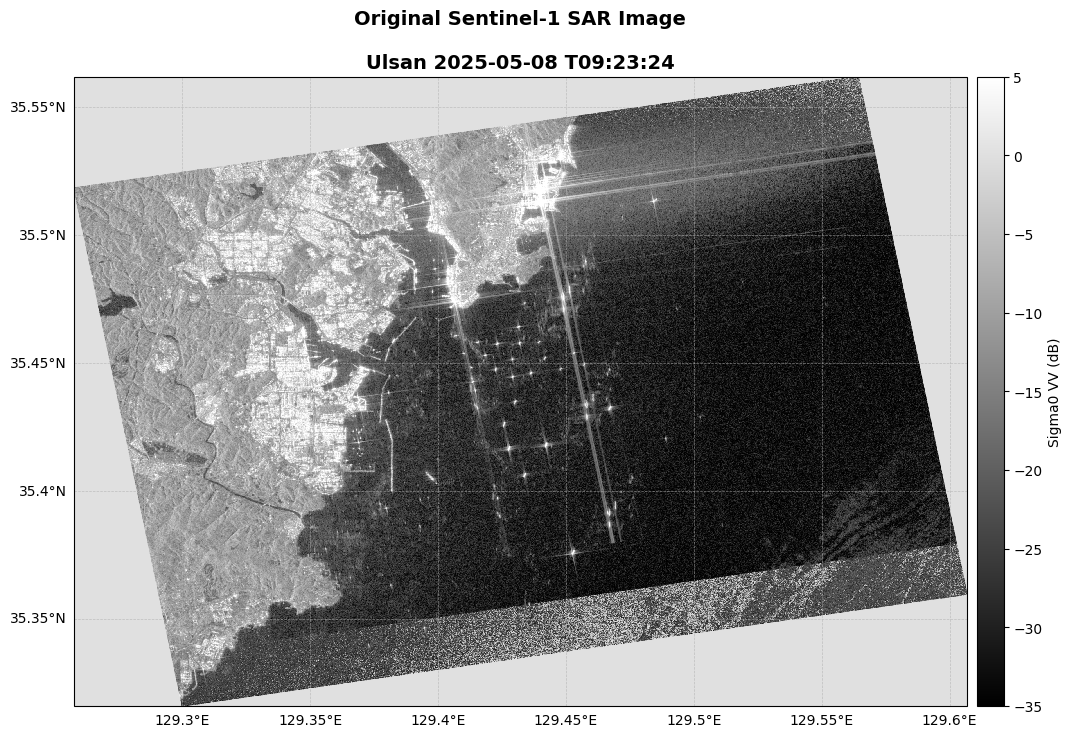

Saved original SAR lon/lat figure: /content/drive/MyDrive/SAR_AI_Ship_Detection/Ulsan_20250508T092324_Original_SAR_Image.png


In [ ]:
# ============================================================
# Original SAR Image Visualization with Lat/Lon Grid
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------------------------------------------
# 1. Use existing variables from previous cell
#    Required: sar_db, xx, yy
# ------------------------------------------------------------

ds = 1

lon = xx[::ds, ::ds]
lat = yy[::ds, ::ds]
sar_plot = sar_db[::ds, ::ds]

# 크기 맞추기
nrow = min(lon.shape[0], lat.shape[0], sar_plot.shape[0])
ncol = min(lon.shape[1], lat.shape[1], sar_plot.shape[1])

lon = lon[:nrow, :ncol]
lat = lat[:nrow, :ncol]
sar_plot = sar_plot[:nrow, :ncol]

# 보기 좋게 dB 범위 제한
sar_plot = np.clip(sar_plot, -35, 5)

# 선택: 약한 smoothing
sar_plot_show = cv2.GaussianBlur(
    sar_plot,
    (3, 3),
    0
)

# ------------------------------------------------------------
# 2. Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([
    np.nanmin(lon), np.nanmax(lon),
    np.nanmin(lat), np.nanmax(lat)
], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon,
    lat,
    sar_plot_show,
    cmap="gray",
    shading="auto",
    vmin=-35,
    vmax=5,
    transform=ccrs.PlateCarree()
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.7
)

gl.top_labels = False
gl.right_labels = False

plt.title(
    "Original Sentinel-1 SAR Image\n"
    "\n"
    "Ulsan 2025-05-08 T09:23:24",
    fontsize=14,
    fontweight="bold"
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.10,
    axes_class=plt.Axes
)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Sigma0 VV (dB)")

SAVE_ORIGINAL_MAP_PATH = (
    "/content/drive/MyDrive/SAR_AI_Ship_Detection/"
    "Ulsan_20250508T092324_Original_SAR_Image.png"
)

plt.savefig(
    SAVE_ORIGINAL_MAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved original SAR lon/lat figure:", SAVE_ORIGINAL_MAP_PATH)